<a href="https://colab.research.google.com/github/gee666thu/r5-machine-learning-lab/blob/main/polynomial_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# Load dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
data = pd.read_csv(url)

In [ ]:
#Select required columns
data = data[['mpg','displacement']]
data.dropna(inplace=True)

print(data.head())
# Features and target
X = data[['displacement']]
y = data['mpg']



    mpg  displacement
0  18.0         307.0
1  15.0         350.0
2  18.0         318.0
3  16.0         304.0
4  17.0         302.0


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Linear Regression")
print("MSE =", mean_squared_error(y_test, y_pred_linear))
print("R2 =", r2_score(y_test, y_pred_linear))
degrees = [2,3,4]

Linear Regression
MSE = 18.102543998358946
R2 = 0.6633114869465596


In [ ]:
for degree in degrees:
    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)

    print("\nDegree =", degree)
    print("MSE =", mean_squared_error(y_test, y_pred))
    print("R2 =", r2_score(y_test, y_pred))


Degree = 2
MSE = 15.10735356108076
R2 = 0.7190189176110284

Degree = 3
MSE = 14.943631793037289
R2 = 0.722063972418907

Degree = 4
MSE = 14.961486893912738
R2 = 0.7217318860908903


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


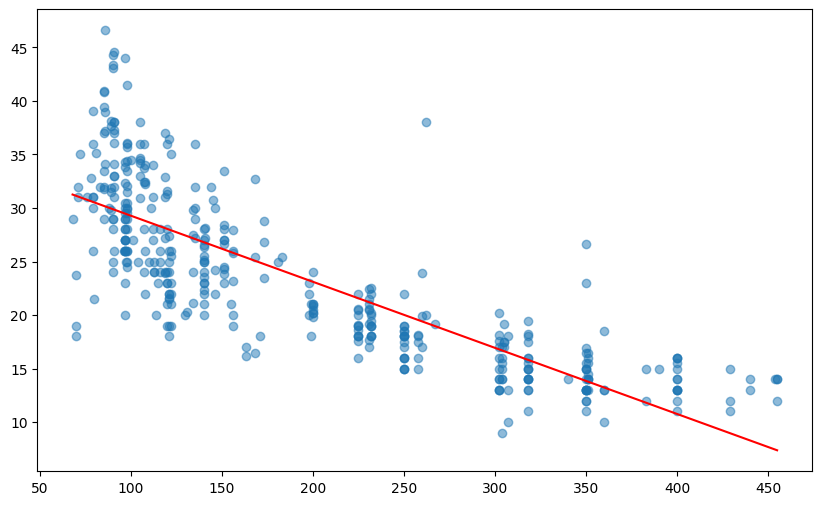

In [ ]:
x_range = np.linspace(X.min(), X.max(), 300).reshape(-1,1)

plt.figure(figsize=(10,6))
plt.scatter(X,y,alpha=0.5,label='Data')

plt.plot(x_range,
         linear_model.predict(x_range),
         color='red',
         label='Linear Regression')



In [ ]:
colors=['green','orange','purple']

for degree,color in zip([2,3,4],colors):
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly,y)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


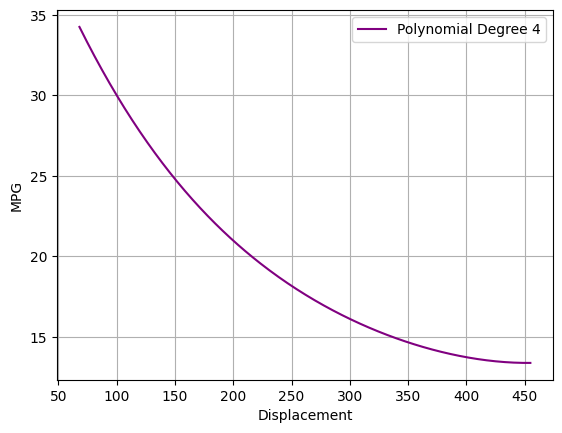

In [ ]:
plt.plot(x_range,
             model.predict(poly.transform(x_range)),
             color=color,
             label=f'Polynomial Degree {degree}')

plt.xlabel("Displacement")
plt.ylabel("MPG")
plt.legend()
plt.grid()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


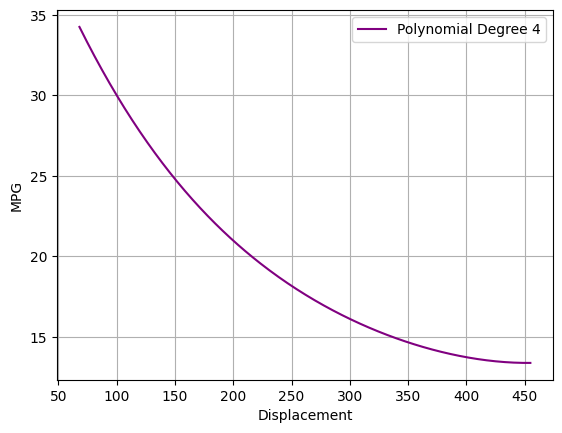

In [ ]:
 plt.plot(x_range,
             model.predict(poly.transform(x_range)),
             color=color,
             label=f'Polynomial Degree {degree}')

plt.xlabel("Displacement")
plt.ylabel("MPG")
plt.legend()
plt.grid()
plt.show()